# Dataset plots

Visualization and threshold tuning for eye gesture event detection.

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analyze import analyze_file
from src.blink_signal import has_blink_columns
from src.detection_config import DetectionConfig
from src.gaze_signal import has_gaze_columns
from src.io_utils import collect_csv_files
from src.plots import plot_blink_signal, plot_combined_overview, plot_detected_events, plot_gaze_speed

DATA_DIR = PROJECT_ROOT / "data"
cfg = DetectionConfig()
files = collect_csv_files(DATA_DIR)
files[:5], len(files)

([PosixPath('/Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification/data/BlinkData_20260504_192616.csv'),
  PosixPath('/Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification/data/BlinkData_20260504_192633.csv'),
  PosixPath('/Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification/data/BlinkData_20260504_192700.csv'),
  PosixPath('/Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification/data/CombinedGestureData_20260504_191953.csv'),
  PosixPath('/Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification/data/CombinedGestureData_20260504_192044.csv')],
 13)

Possible thresholds adjustments here

In [ ]:
cfg = DetectionConfig(
    fixation_speed_threshold_deg_s=30.0,
    saccade_speed_threshold_deg_s=120.0,
    blink_threshold=0.60,
)

In [ ]:
sample_path = files[0]
df, events = analyze_file(sample_path, cfg)
sample_path.name, events.head()

('BlinkData_20260504_192616.csv',
                      source_file      phase gesture start_time_s end_time_s  \
 0  BlinkData_20260504_192616.csv  recording   blink        2.473      2.562   
 1  BlinkData_20260504_192616.csv  recording   blink        3.809      3.932   
 2  BlinkData_20260504_192616.csv  recording   blink        5.346      5.502   
 3  BlinkData_20260504_192616.csv  recording   blink        6.772      6.995   
 4  BlinkData_20260504_192616.csv  recording   blink        8.342      8.499   
 
   duration_ms peak_value sample_count  
 0        89.0    0.96894            9  
 1       123.0   0.976725           12  
 2       156.0   0.989295           15  
 3       223.0        1.0           21  
 4       157.0   0.999755           15  )

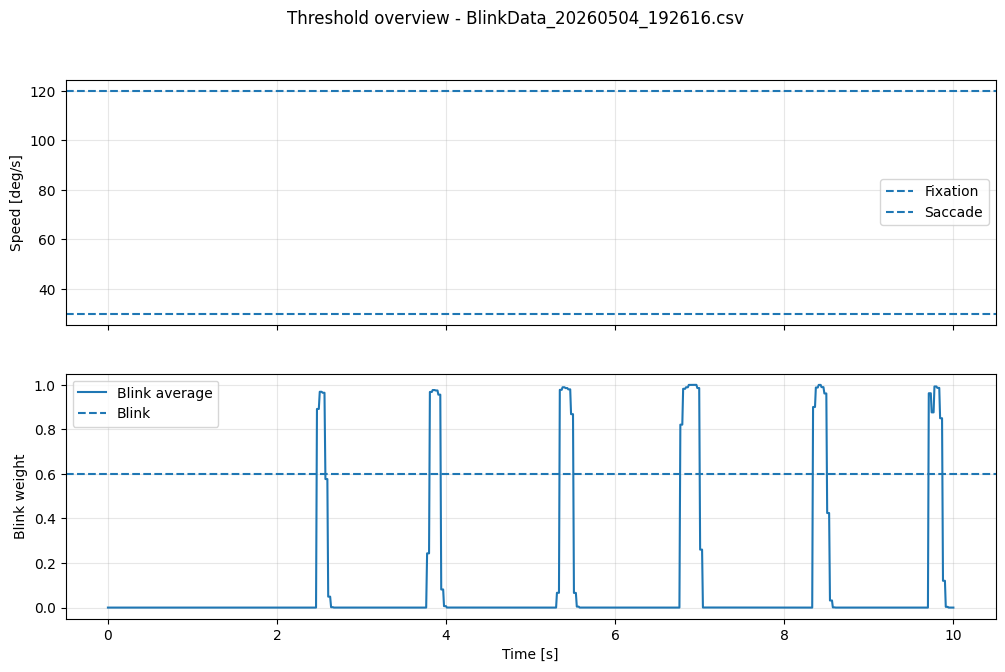

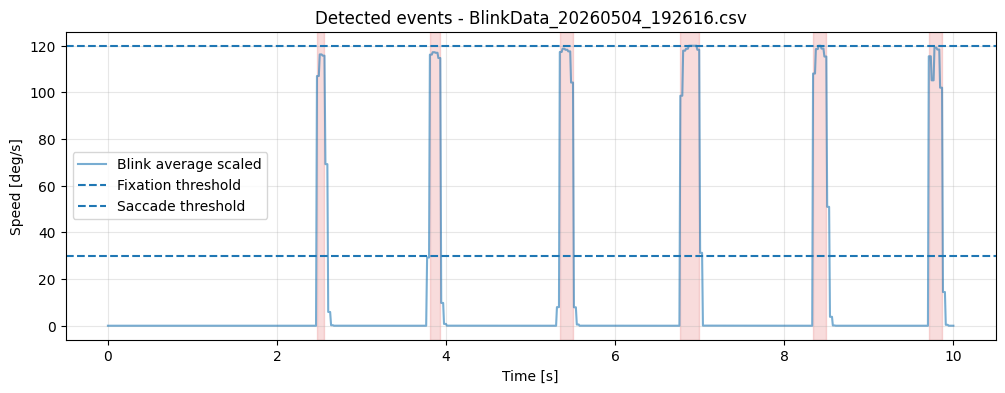

In [ ]:
plot_combined_overview(df, cfg)
plot_detected_events(df, events, cfg);

/Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification/src/plots.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12, 4))


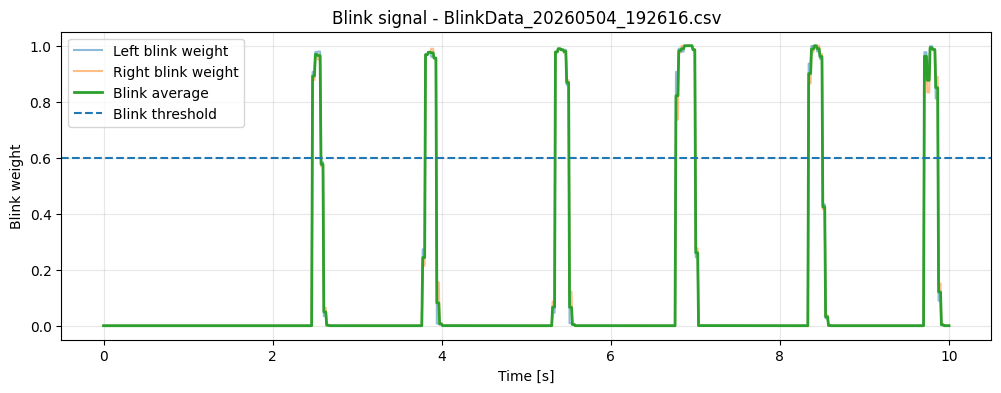

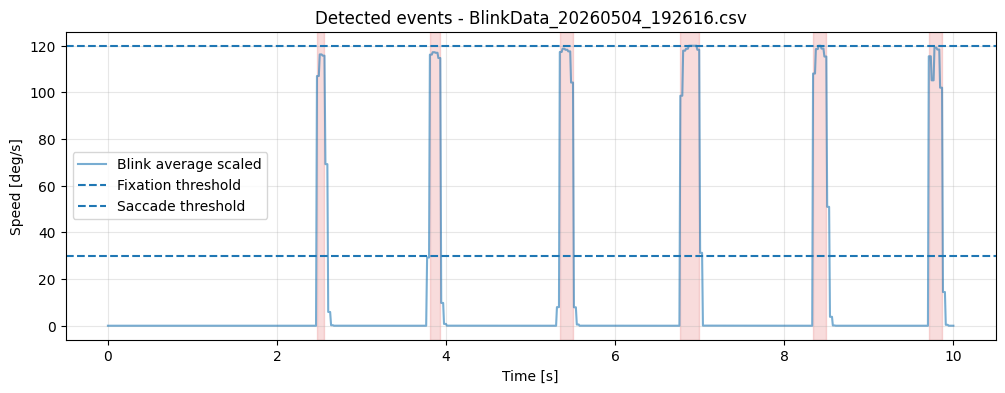

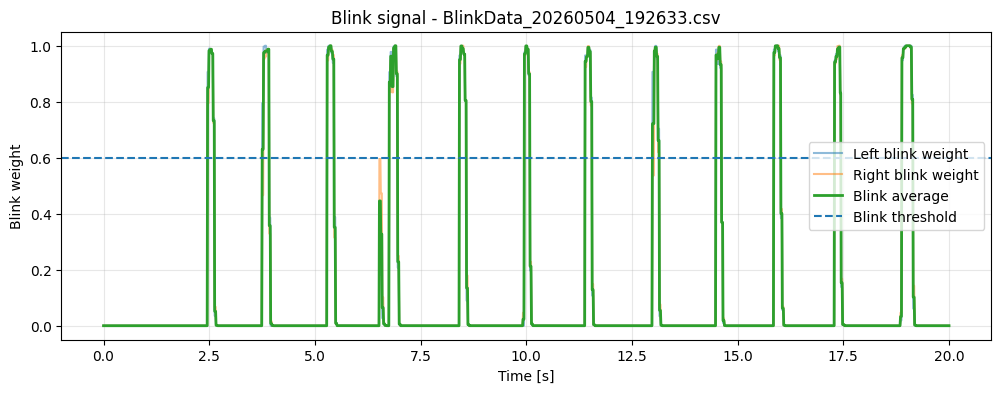

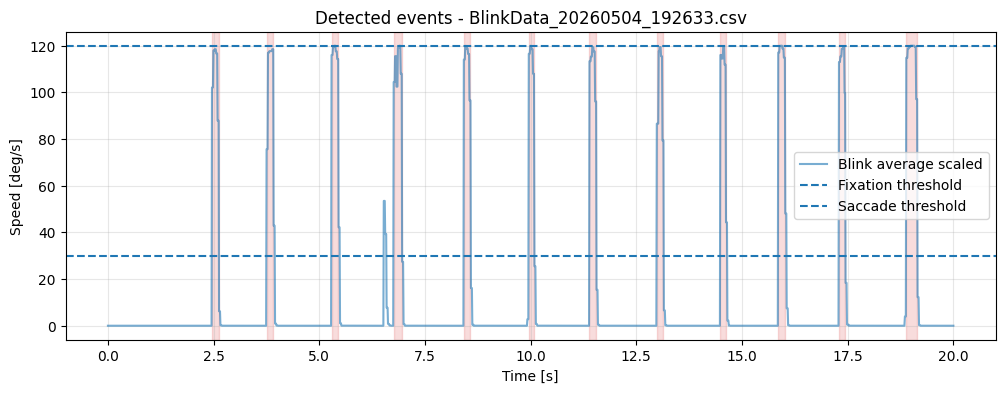

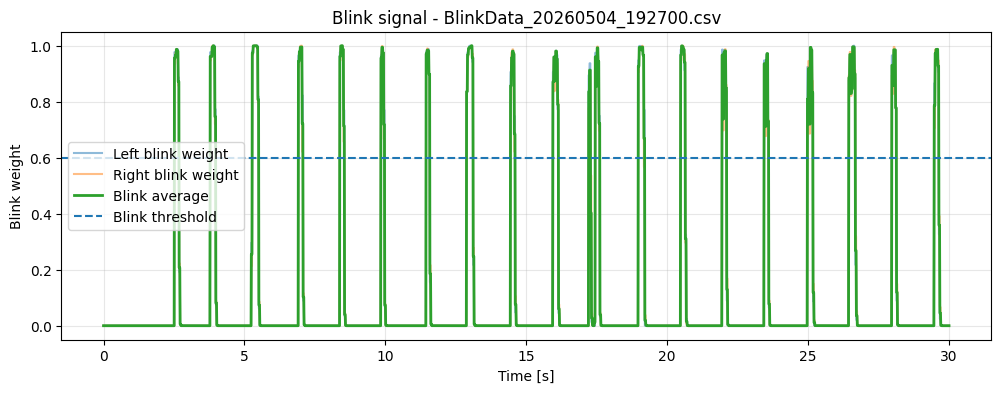

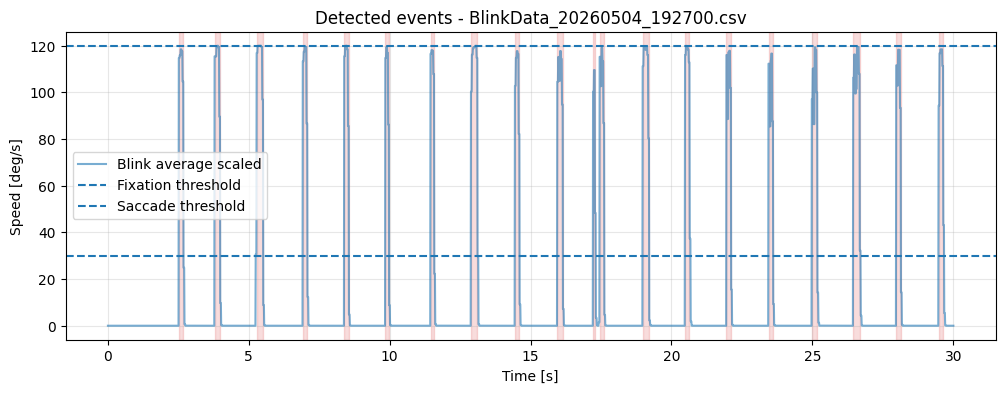

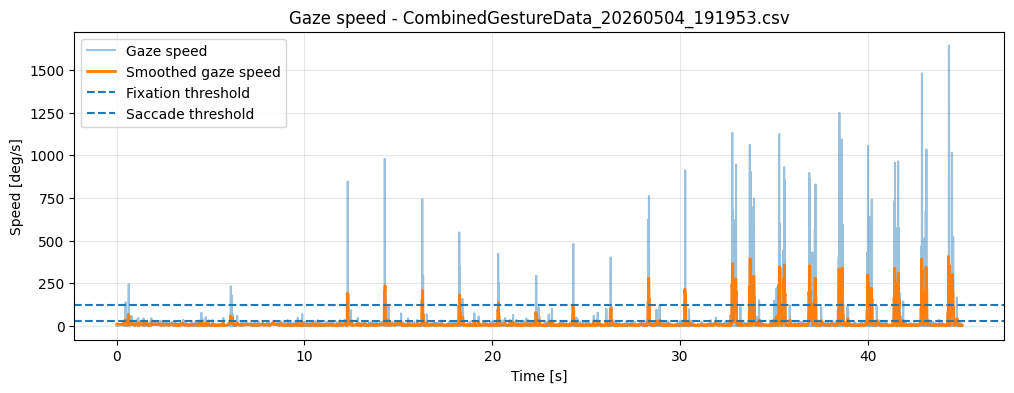

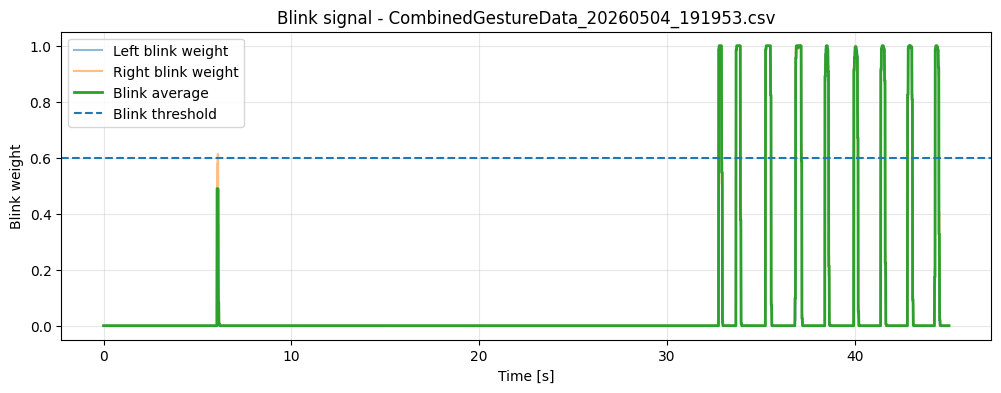

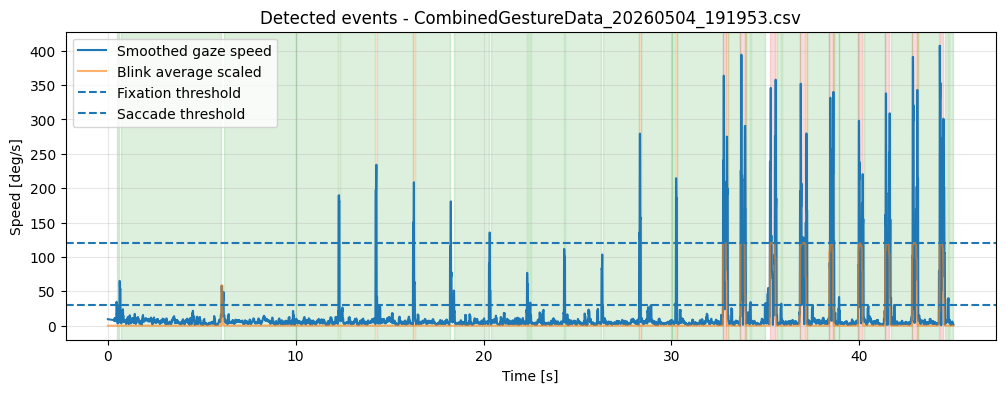

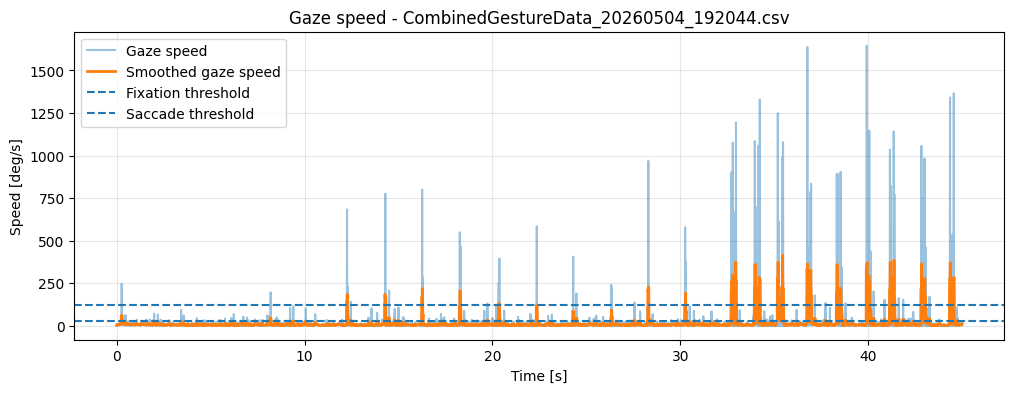

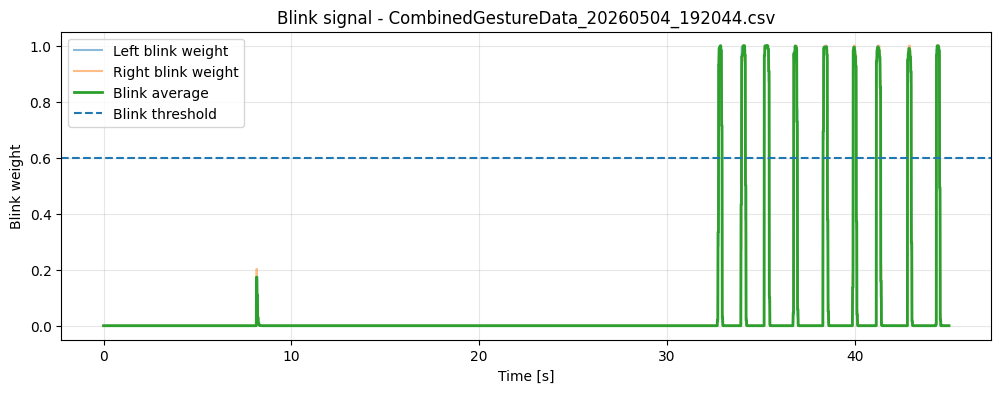

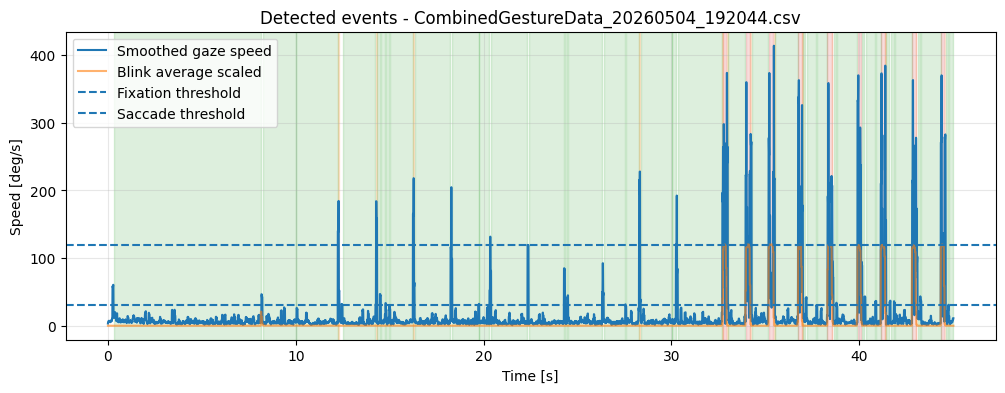

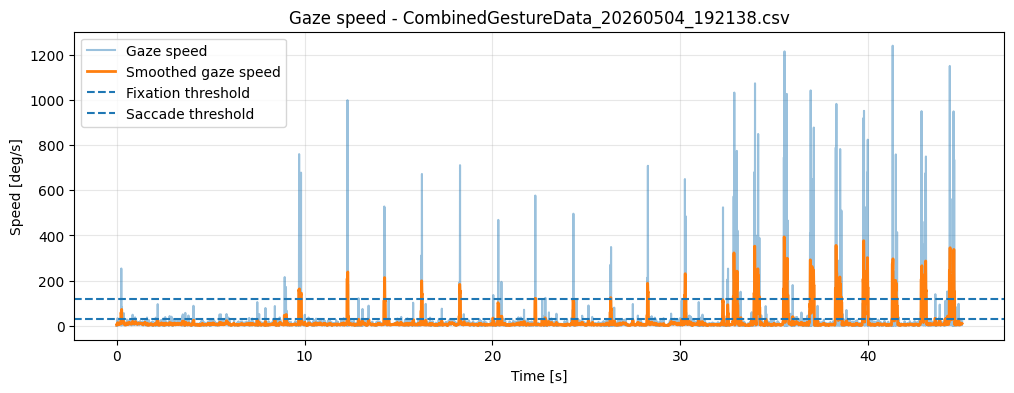

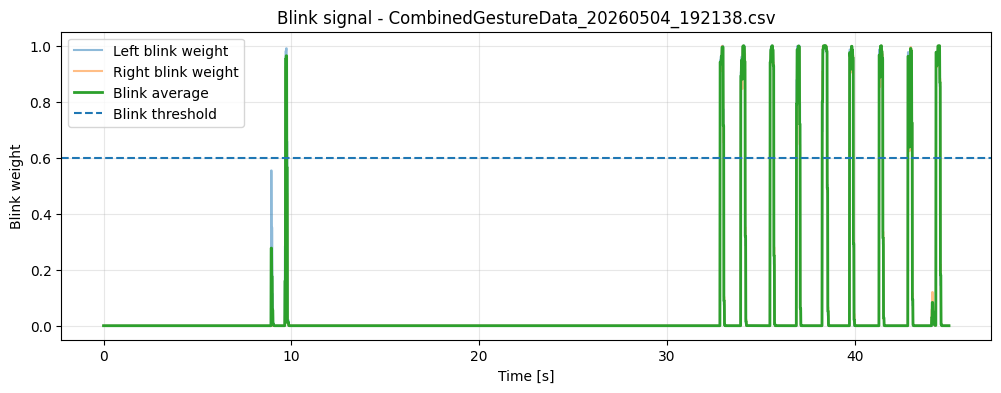

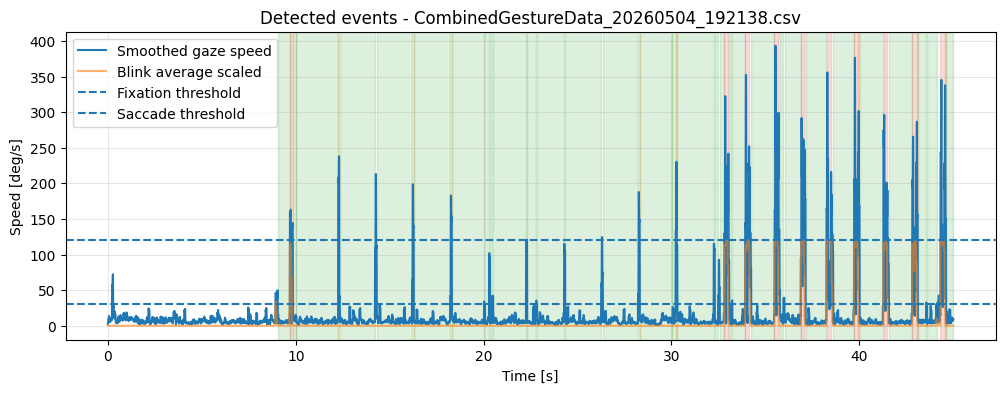

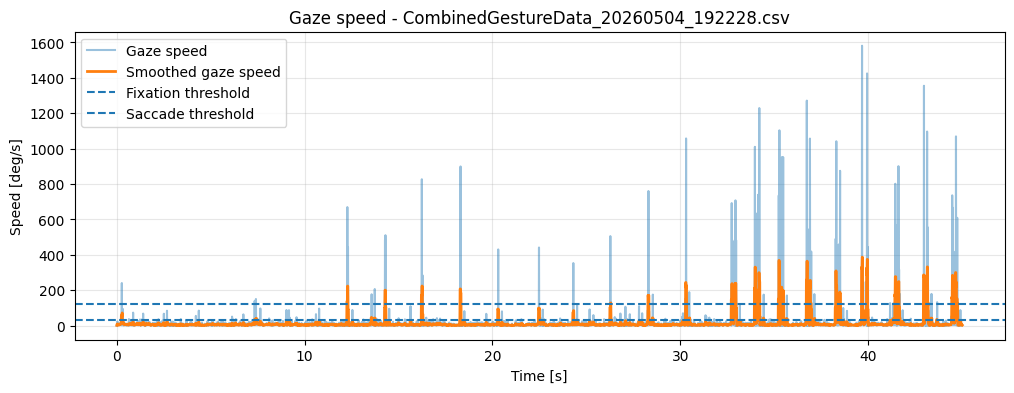

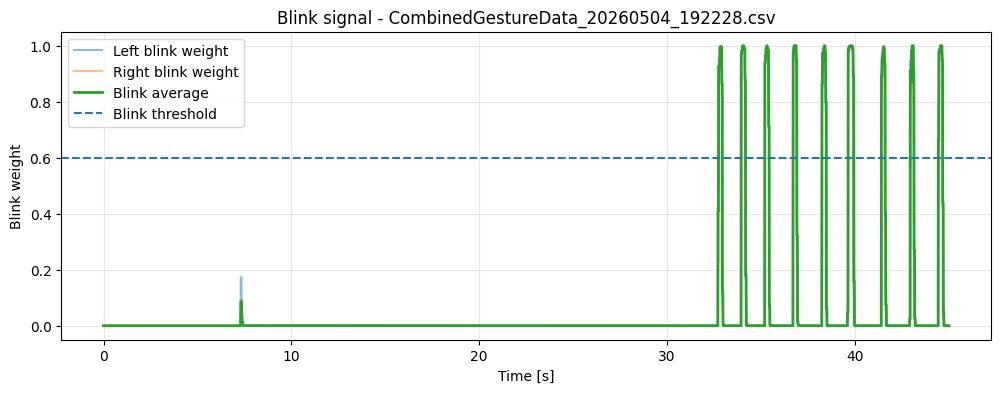

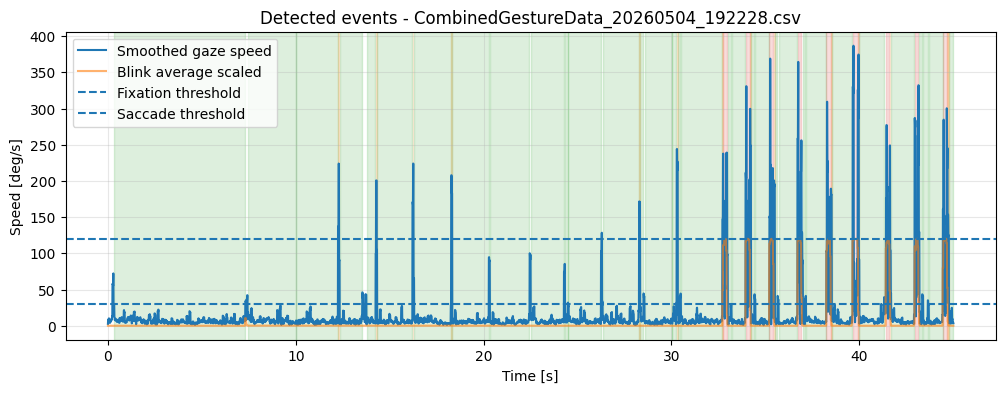

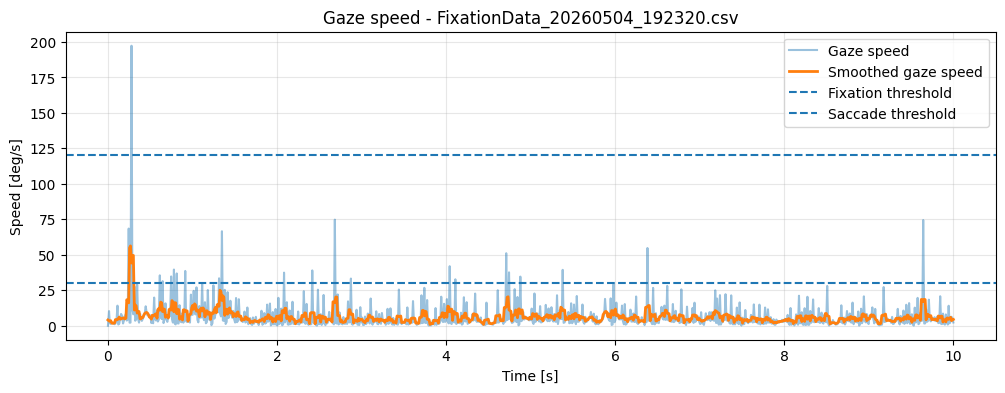

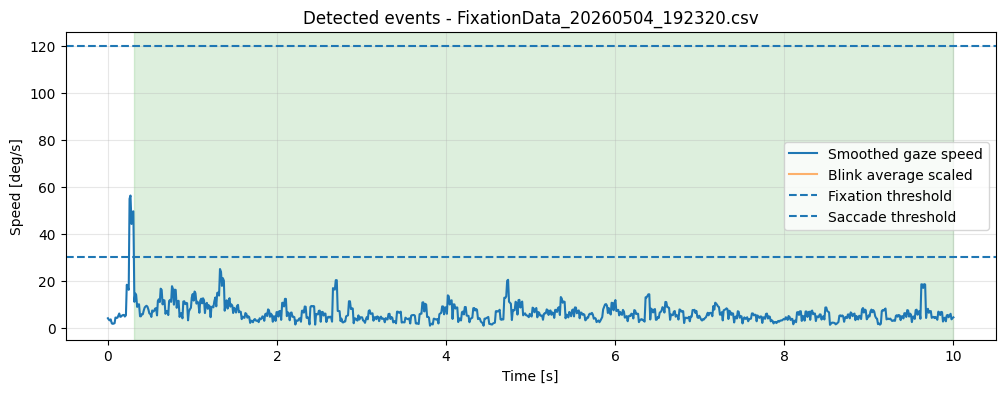

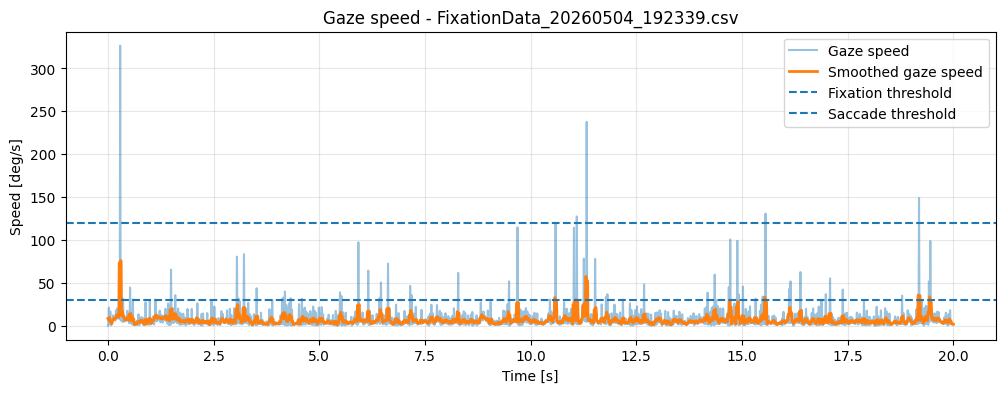

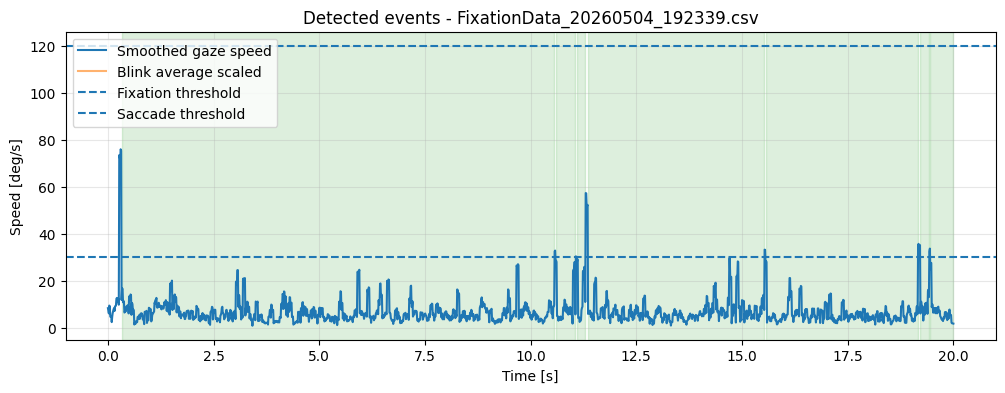

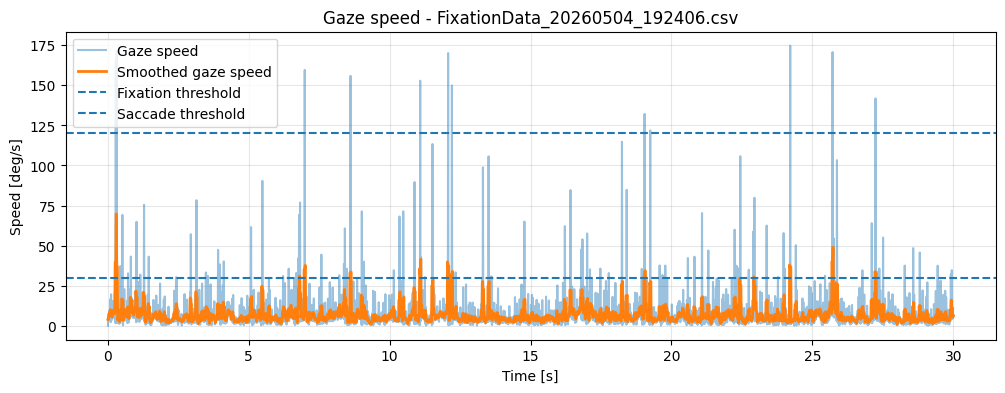

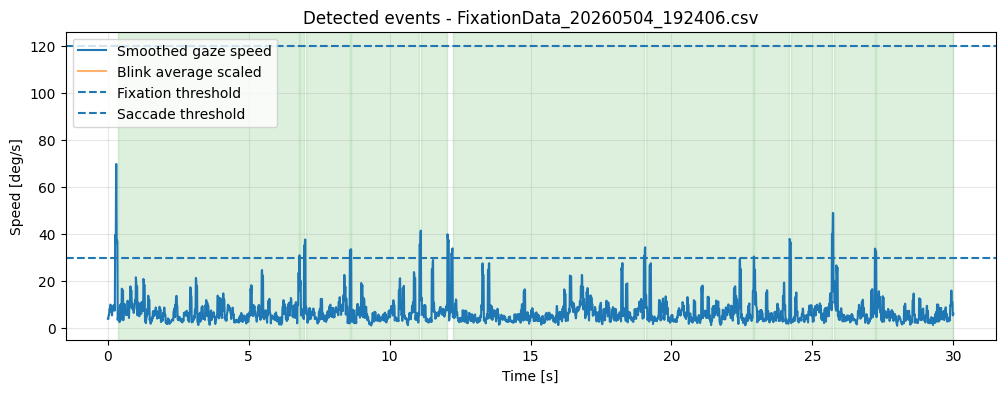

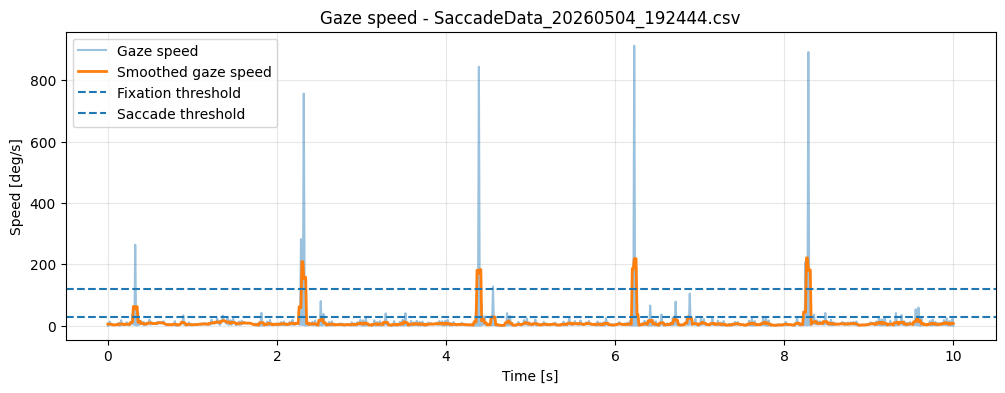

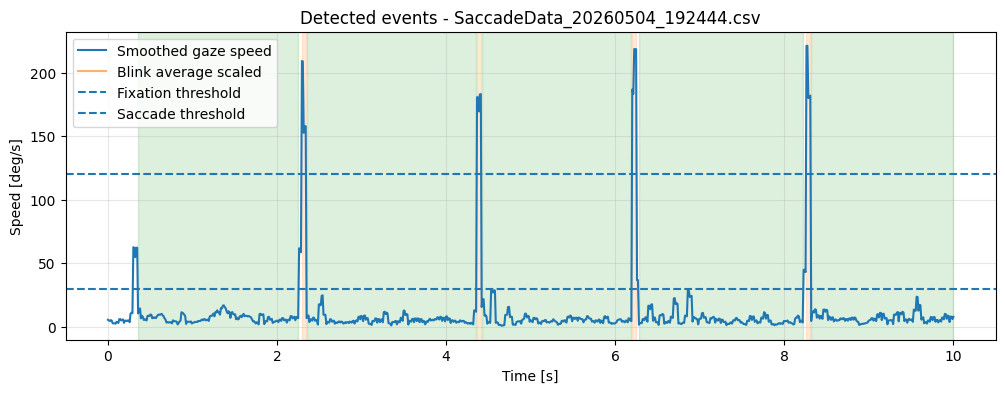

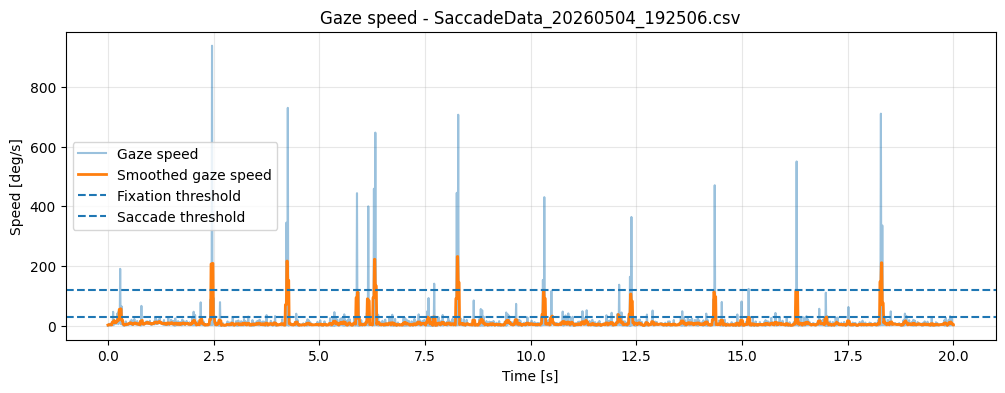

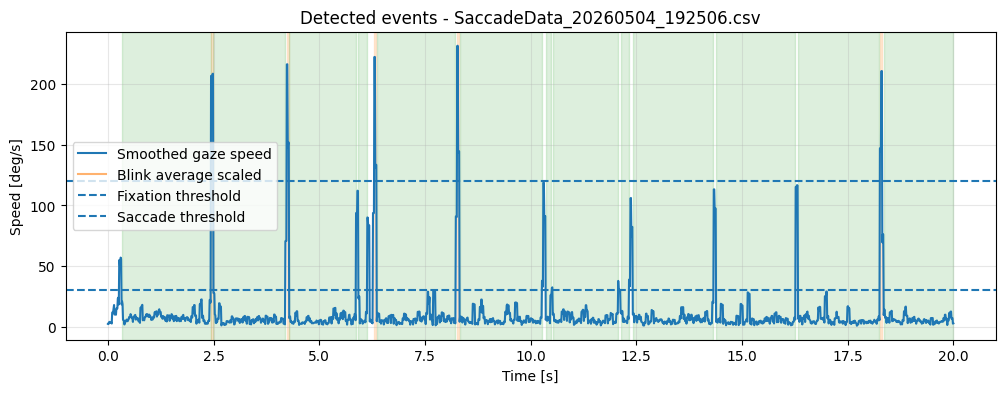

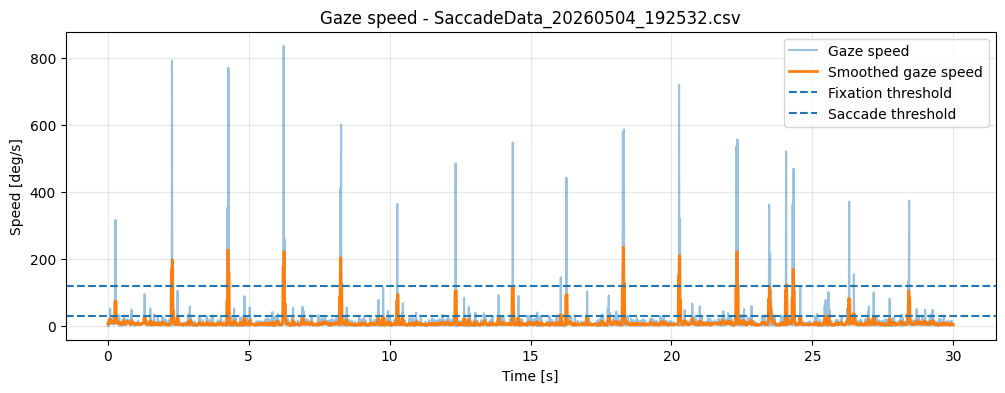

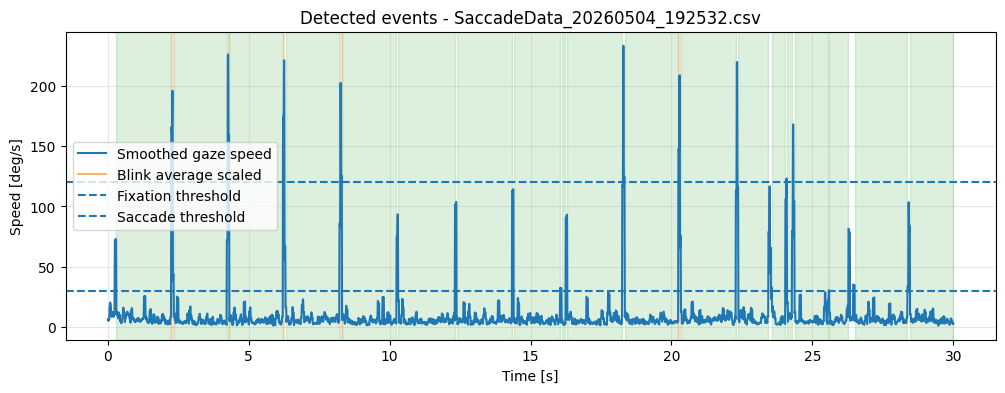

In [ ]:
for path in files:
    df, events = analyze_file(path, cfg)
    if has_gaze_columns(df):
        plot_gaze_speed(df, cfg)
    if has_blink_columns(df):
        plot_blink_signal(df, cfg)
    plot_detected_events(df, events, cfg)